In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [ ]:
import os

DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

In [ ]:
df = pd.read_excel(
    os.path.join(OUTPUT_DIR, "dataset_with_sentiment.xlsx")
)

In [3]:
print(df.columns.tolist())

['tweet_id', 'display_name', 'username', 'followers', 'tweet', 'created_at', 'lang', 'user_location', 'tweet_location', 'likes', 'retweets', 'replies', 'mentions', 'reply_to_username', 'tweet_clean', 'region', 'location_clean', 'city_clean', 'sentiment_roberta', 'confidence_roberta', 'polarity_roberta', 'sentiment_model2', 'confidence_model2', 'polarity_model2', 'sentiment', 'sentiment_score']


In [4]:
df["created_at"] = pd.to_datetime(
    df["created_at"]
)

C:\Users\HP\AppData\Local\Temp\ipykernel_7452\1483581129.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["created_at"] = pd.to_datetime(


In [5]:
df["created_at"].head()

0   2021-06-21 13:42:22+00:00
1   2021-06-28 14:24:52+00:00
2   2021-06-25 17:52:01+00:00
3   2021-06-28 12:50:20+00:00
4   2021-06-24 05:46:42+00:00
Name: created_at, dtype: datetime64[us, UTC]

In [6]:
#cek rentang data
print(
    "Start:",
    df["created_at"].min()
)

print(
    "End:",
    df["created_at"].max()
)

Start: 2021-01-02 02:56:55+00:00
End: 2025-12-29 09:40:40+00:00


---------------------Tweet Volume Over Time---------------------------------

In [7]:
daily_tweets = (
    df
    .groupby(
        df["created_at"].dt.date
    )
    .size()
    .reset_index(
        name="tweet_count"
    )
)

daily_tweets.columns = [
    "date",
    "tweet_count"
]

In [8]:
daily_tweets.head()

,date,tweet_count
0,2021-01-02,3
1,2021-01-03,1
2,2021-01-04,2
3,2021-01-05,2
4,2021-01-06,2


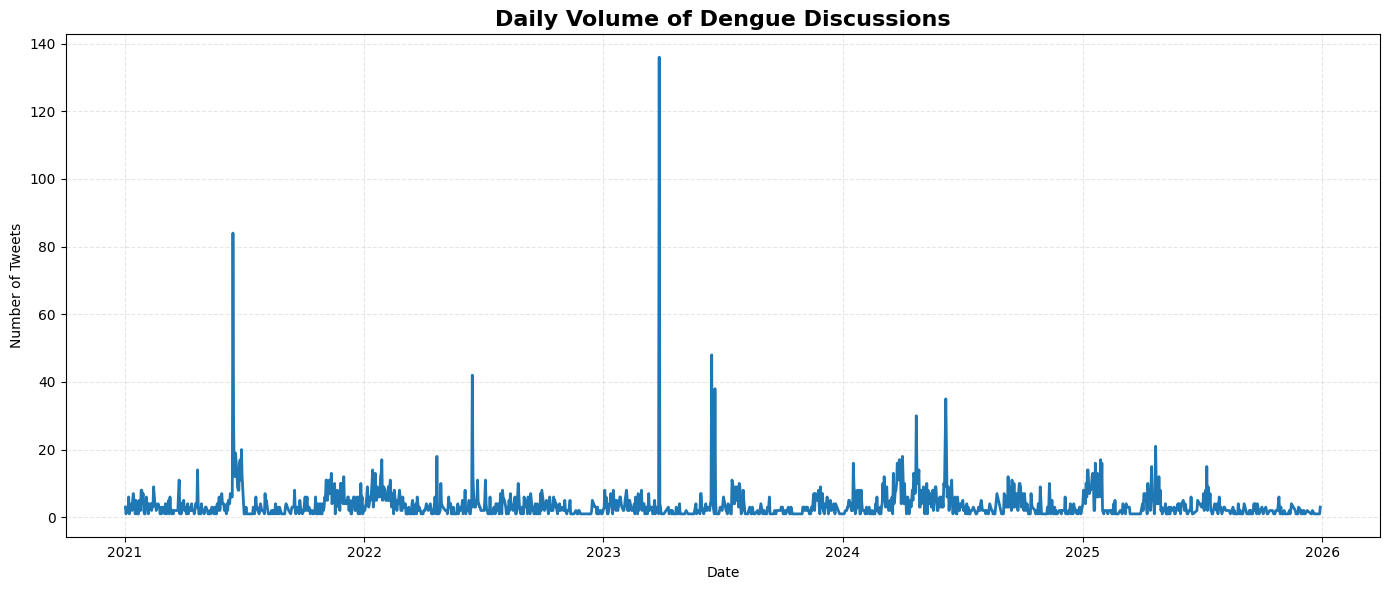

In [9]:
plt.figure(
    figsize=(14,6)
)

plt.plot(
    daily_tweets["date"],
    daily_tweets["tweet_count"],
    linewidth=2
)

plt.title(
    "Daily Volume of Dengue Discussions",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date")

plt.ylabel(
    "Number of Tweets"
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

Using Rolling Average

In [10]:
daily_tweets["rolling_7d"] = (
    daily_tweets["tweet_count"]
    .rolling(7)
    .mean()
)

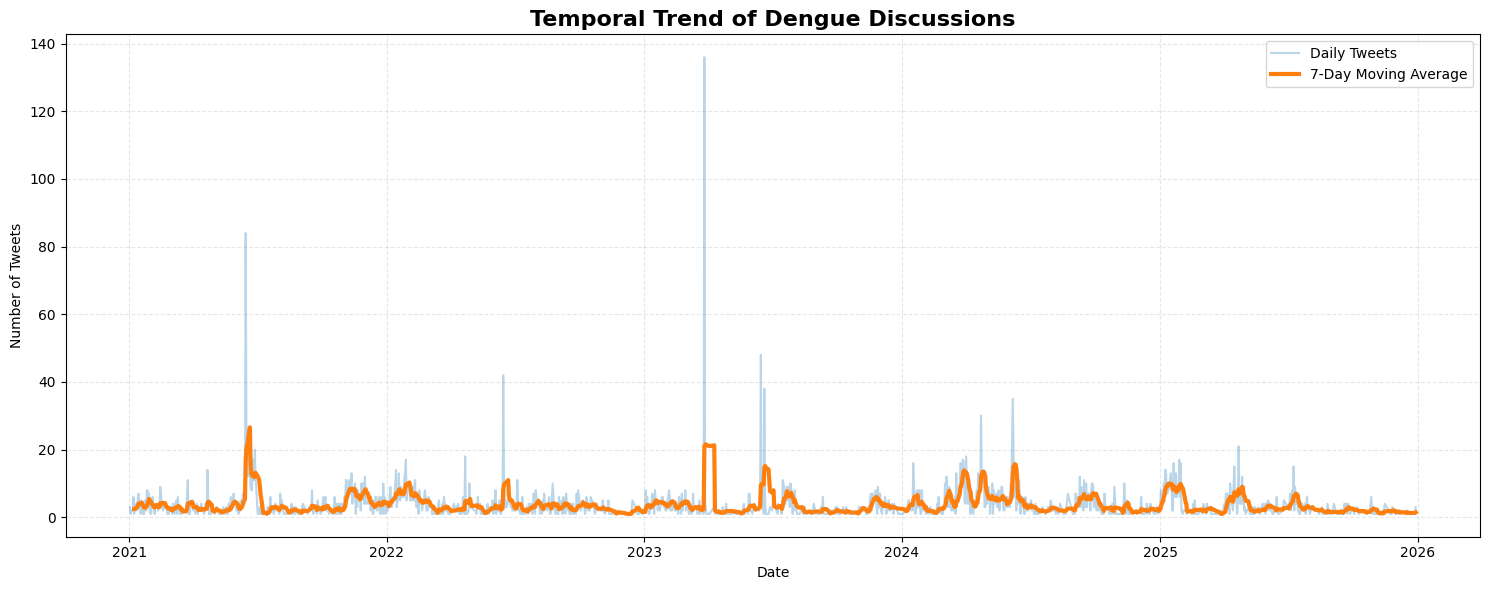

In [11]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    daily_tweets["date"],
    daily_tweets["tweet_count"],
    alpha=0.3,
    label="Daily Tweets"
)

plt.plot(
    daily_tweets["date"],
    daily_tweets["rolling_7d"],
    linewidth=3,
    label="7-Day Moving Average"
)

plt.title(
    "Temporal Trend of Dengue Discussions",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date")

plt.ylabel(
    "Number of Tweets"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "tweet_volume_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
print(df.columns.tolist())
print(df["created_at"].min())
print(df["created_at"].max())

['tweet_id', 'display_name', 'username', 'followers', 'tweet', 'created_at', 'lang', 'user_location', 'tweet_location', 'likes', 'retweets', 'replies', 'mentions', 'reply_to_username', 'tweet_clean', 'region', 'location_clean', 'city_clean', 'sentiment_roberta', 'confidence_roberta', 'polarity_roberta', 'sentiment_model2', 'confidence_model2', 'polarity_model2', 'sentiment', 'sentiment_score']
2021-01-02 02:56:55+00:00
2025-12-29 09:40:40+00:00


----monthly discussion pattern----

In [13]:
monthly_tweets = (
    df
    .groupby(
        df["created_at"].dt.to_period("M")
    )
    .size()
    .reset_index(
        name="tweet_count"
    )
)

monthly_tweets["month"] = (
    monthly_tweets["created_at"]
    .astype(str)
)

C:\Users\HP\AppData\Local\Temp\ipykernel_7452\1871909172.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["created_at"].dt.to_period("M")


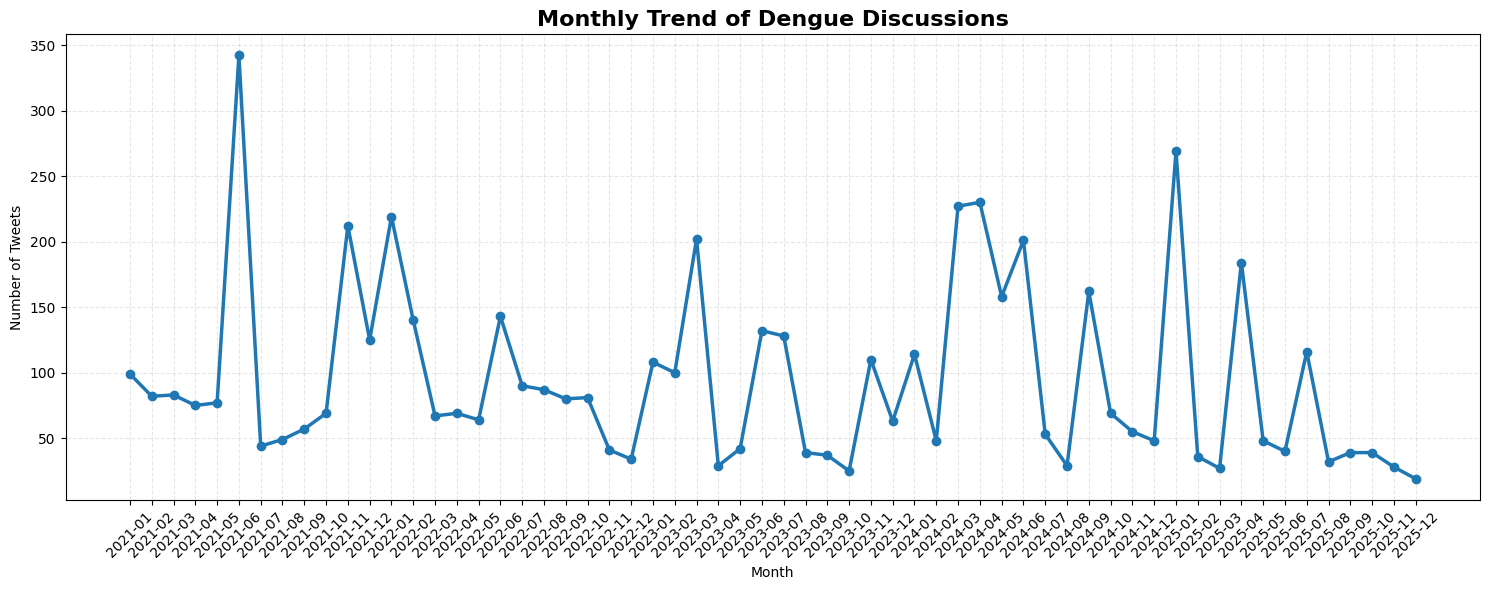

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_tweets["month"],
    monthly_tweets["tweet_count"],
    marker="o",
    linewidth=2.5
)

plt.title(
    "Monthly Trend of Dengue Discussions",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Tweets")

plt.xticks(
    rotation=45
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [15]:
monthly_tweets["rolling_3m"] = (
    monthly_tweets["tweet_count"]
    .rolling(3)
    .mean()
)

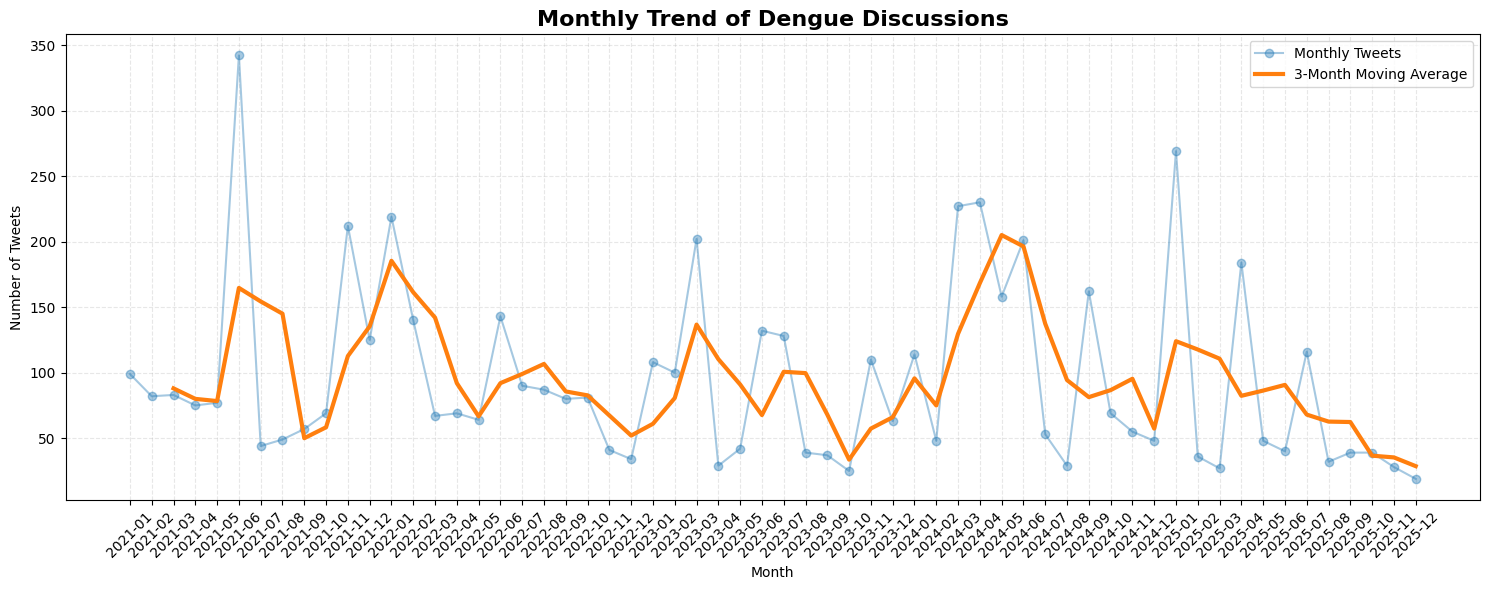

In [16]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_tweets["month"],
    monthly_tweets["tweet_count"],
    alpha=0.4,
    marker="o",
    label="Monthly Tweets"
)

plt.plot(
    monthly_tweets["month"],
    monthly_tweets["rolling_3m"],
    linewidth=3,
    label="3-Month Moving Average"
)

plt.title(
    "Monthly Trend of Dengue Discussions",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=45)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [17]:
monthly_tweets.head()

,created_at,tweet_count,month,rolling_3m
0,2021-01,99,2021-01,NaN
1,2021-02,82,2021-02,NaN
2,2021-03,83,2021-03,88.000000
3,2021-04,75,2021-04,80.000000
4,2021-05,77,2021-05,78.333333


In [ ]:
monthly_tweets.to_excel(
    os.path.join(OUTPUT_DIR, "monthly_tweets.xlsx"),
    index=False
)

----------------Sentiment Evolution Over Time-----------------------

In [19]:
sentiment_monthly = (
    df
    .groupby(
        [
            df["created_at"].dt.to_period("M"),
            "sentiment"
        ]
    )
    .size()
    .reset_index(
        name="tweet_count"
    )
)

sentiment_monthly["month"] = (
    sentiment_monthly["created_at"]
    .astype(str)
)

sentiment_monthly.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_7452\836257440.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["created_at"].dt.to_period("M"),


,created_at,sentiment,tweet_count,month
0,2021-01,negative,29,2021-01
1,2021-01,neutral,47,2021-01
2,2021-01,positive,23,2021-01
3,2021-02,negative,26,2021-02
4,2021-02,neutral,49,2021-02


In [ ]:
sentiment_monthly.to_excel(
    os.path.join(OUTPUT_DIR, "sentiment_monthly.xlsx"),
    index=False
)

In [21]:
sentiment_pivot = (
    sentiment_monthly
    .pivot(
        index="month",
        columns="sentiment",
        values="tweet_count"
    )
    .fillna(0)
)

sentiment_pivot.head()

sentiment,negative,neutral,positive
month,,,
2021-01,29.0,47.0,23.0
2021-02,26.0,49.0,7.0
2021-03,19.0,40.0,24.0
2021-04,24.0,35.0,16.0
2021-05,26.0,42.0,9.0


In [22]:
sentiment_pivot.index = pd.to_datetime(
    sentiment_pivot.index
)

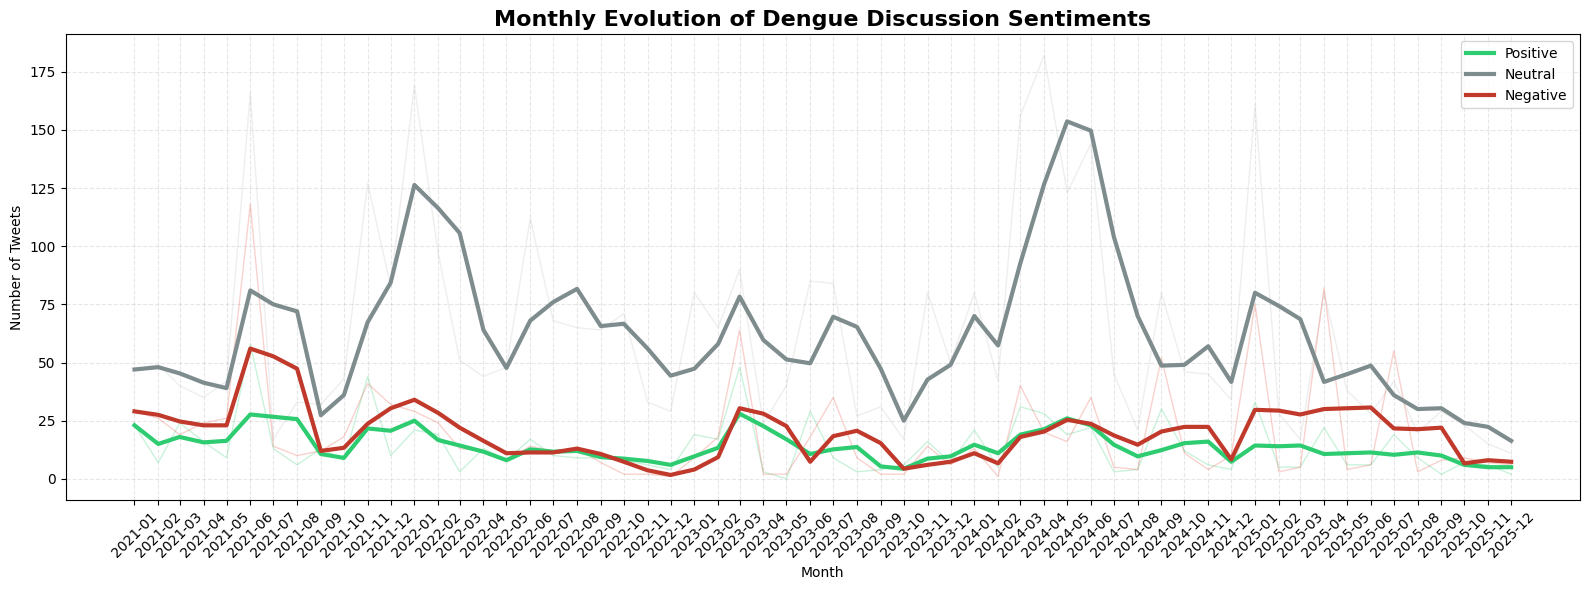

In [23]:
import matplotlib.pyplot as plt

sentiment_smooth = (
    sentiment_pivot
    .rolling(
        3,
        min_periods=1
    )
    .mean()
)

plt.figure(
    figsize=(16,6)
)

# raw lines (tipis)

plt.plot(
    sentiment_pivot.index,
    sentiment_pivot["positive"],
    color="#2ECC71",
    alpha=0.25,
    linewidth=1
)

plt.plot(
    sentiment_pivot.index,
    sentiment_pivot["neutral"],
    color="#BDBDBD",
    alpha=0.25,
    linewidth=1
)

plt.plot(
    sentiment_pivot.index,
    sentiment_pivot["negative"],
    color="#E74C3C",
    alpha=0.25,
    linewidth=1
)

# moving average

plt.plot(
    sentiment_smooth.index,
    sentiment_smooth["positive"],
    color="#2ECC71",
    linewidth=3,
    label="Positive"
)

plt.plot(
    sentiment_smooth.index,
    sentiment_smooth["neutral"],
    color="#7F8C8D",
    linewidth=3,
    label="Neutral"
)

plt.plot(
    sentiment_smooth.index,
    sentiment_smooth["negative"],
    color="#C0392B",
    linewidth=3,
    label="Negative"
)

plt.title(
    "Monthly Evolution of Dengue Discussion Sentiments",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Tweets")

plt.xticks(
    sentiment_pivot.index,
    sentiment_pivot.index.strftime("%Y-%m"),
    rotation=45
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sentiment_evolution_monthly_ma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

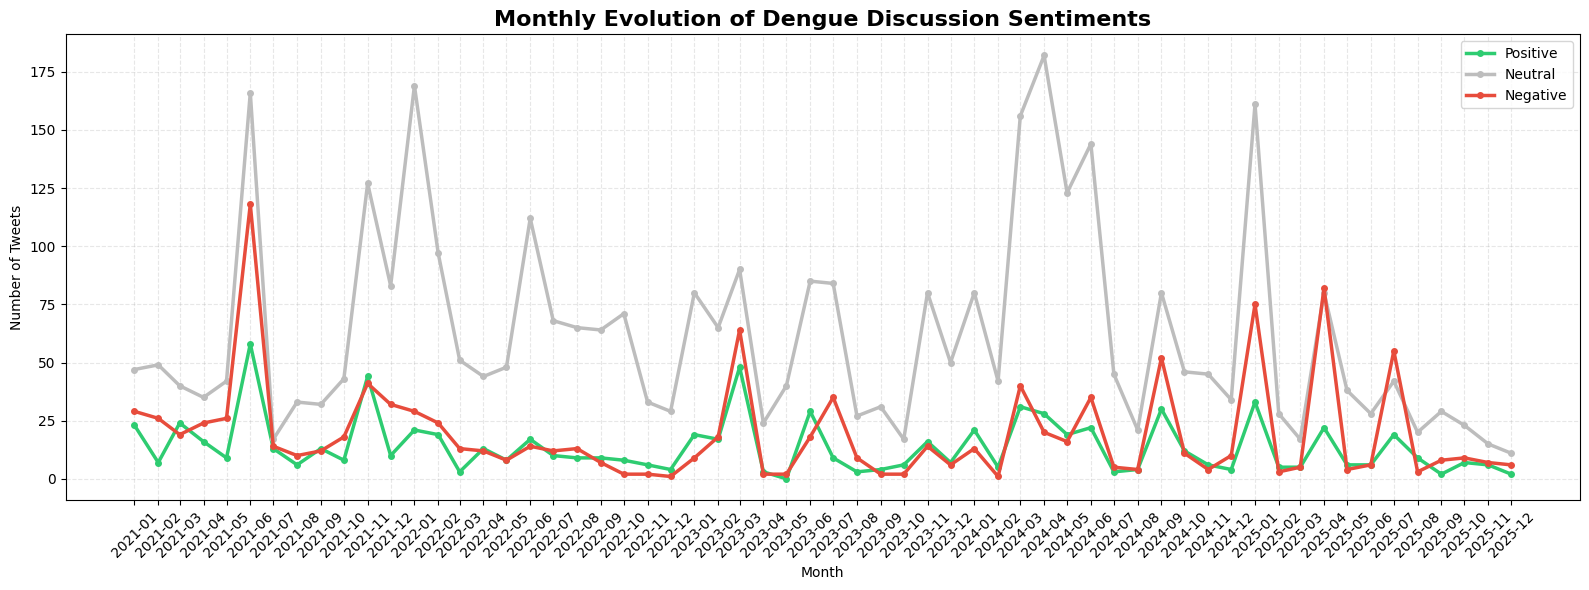

In [24]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(16,6)
)

plt.plot(
    sentiment_pivot.index,
    sentiment_pivot["positive"],
    linewidth=2.5,
    label="Positive",
    color="#2ECC71",
    marker="o",
    markersize=4
)

plt.plot(
    sentiment_pivot.index,
    sentiment_pivot["neutral"],
    linewidth=2.5,
    label="Neutral",
    color="#BDBDBD",
    marker="o",
    markersize=4
)

plt.plot(
    sentiment_pivot.index,
    sentiment_pivot["negative"],
    linewidth=2.5,
    label="Negative",
    color="#E74C3C",
    marker="o",
    markersize=4
)

plt.title(
    "Monthly Evolution of Dengue Discussion Sentiments",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Tweets")

plt.xticks(
    sentiment_pivot.index,
    sentiment_pivot.index.strftime("%Y-%m"),
    rotation=45
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sentiment_evolution_monthly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

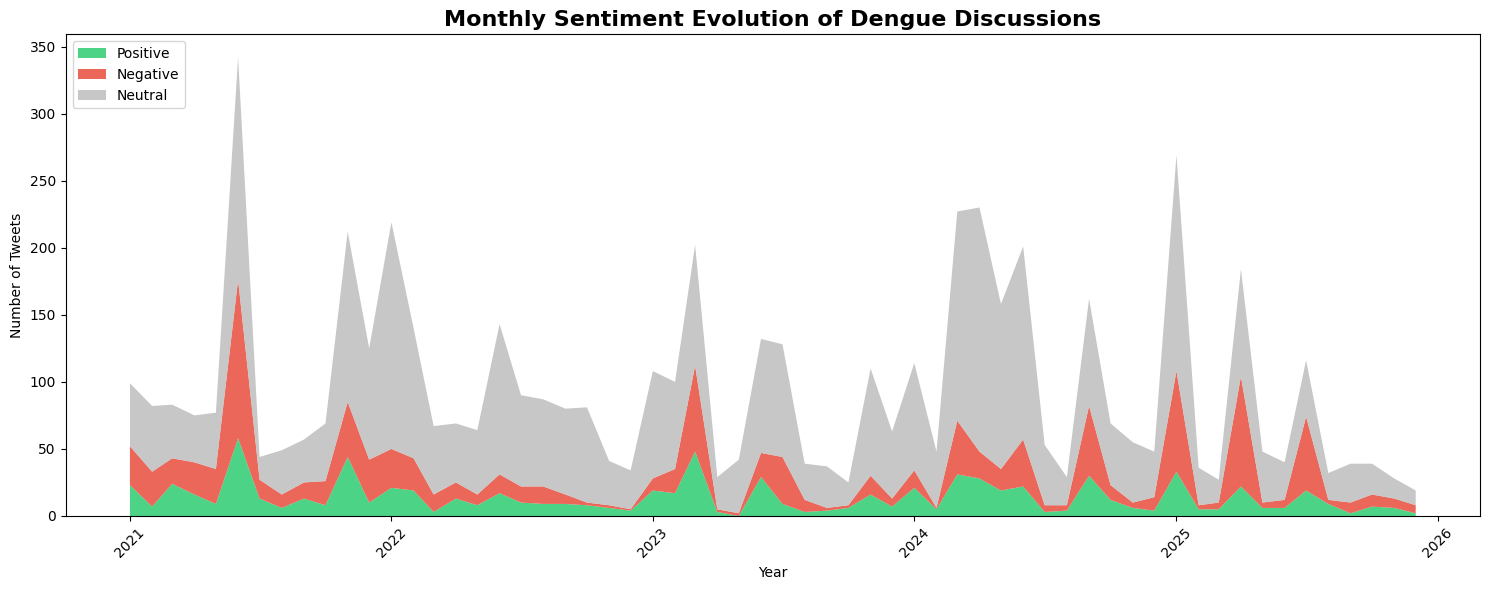

In [25]:
import matplotlib.dates as mdates
plt.figure(
    figsize=(15,6)
)

plt.stackplot(
    sentiment_pivot.index,

    sentiment_pivot["positive"],
    sentiment_pivot["negative"],
    sentiment_pivot["neutral"],

    labels=[
        "Positive",
        "Negative",
        "Neutral"
    ],

    colors=[
        "#2ECC71",
        "#E74C3C",
        "#BDBDBD"
    ],

    alpha=0.85
)

plt.title(
    "Monthly Sentiment Evolution of Dengue Discussions",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")

plt.ylabel(
    "Number of Tweets"
)
plt.xticks(
    sentiment_pivot.index,
    sentiment_pivot.index.strftime("%Y-%m"),
    rotation=45
)

plt.legend(
    loc="upper left"
)

ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

plt.tight_layout()

plt.show()

In [26]:
sentiment_pivot.head()

sentiment,negative,neutral,positive
month,,,
2021-01-01,29.0,47.0,23.0
2021-02-01,26.0,49.0,7.0
2021-03-01,19.0,40.0,24.0
2021-04-01,24.0,35.0,16.0
2021-05-01,26.0,42.0,9.0


In [ ]:
sentiment_pivot.to_excel(
    os.path.join(OUTPUT_DIR, "sentiment_pivot.xlsx")
)

In [27]:
from scipy.stats import pearsonr, spearmanr

# Build monthly negative-sentiment percentage from sentiment_pivot
sentiment_pivot["total"] = (
    sentiment_pivot["positive"]
    + sentiment_pivot["neutral"]
    + sentiment_pivot["negative"]
)
sentiment_pivot["negative_pct"] = (
    sentiment_pivot["negative"] / sentiment_pivot["total"] * 100
)

# Align with monthly_tweets (volume) using the month index
monthly_tweets_indexed = monthly_tweets.set_index(
    pd.to_datetime(monthly_tweets["month"])
)

correlation_df = pd.DataFrame({
    "volume": monthly_tweets_indexed["tweet_count"],
    "negative_pct": sentiment_pivot["negative_pct"]
}).dropna()

print("Months included:", len(correlation_df))
print(correlation_df.head())

Months included: 60
            volume  negative_pct
month                           
2021-01-01      99     29.292929
2021-02-01      82     31.707317
2021-03-01      83     22.891566
2021-04-01      75     32.000000
2021-05-01      77     33.766234


In [28]:
r_pearson, p_pearson = pearsonr(correlation_df["volume"], correlation_df["negative_pct"])
print(f"Pearson r = {r_pearson:.4f}, p = {p_pearson:.4f}")

r_spearman, p_spearman = spearmanr(correlation_df["volume"], correlation_df["negative_pct"])
print(f"Spearman rho = {r_spearman:.4f}, p = {p_spearman:.4f}")

Pearson r = 0.3061, p = 0.0174
Spearman rho = 0.2945, p = 0.0224


In [29]:
len(correlation_df)

60

In [29]:
sentiment_smooth.head()

sentiment,negative,neutral,positive
month,,,
2021-01-01,29.000000,47.000000,23.000000
2021-02-01,27.500000,48.000000,15.000000
2021-03-01,24.666667,45.333333,18.000000
2021-04-01,23.000000,41.333333,15.666667
2021-05-01,23.000000,39.000000,16.333333


In [ ]:
sentiment_smooth.to_excel(
    os.path.join(OUTPUT_DIR, "sentiment_smooth.xlsx")
)

-----------trend per city----------------

In [31]:
selected_cities = [
    "jakarta",
    "yogyakarta",
    "surabaya",
    "bandung",
    "malang",
    "semarang",
    "depok",
    "bekasi",
    "denpasar"
]

In [32]:
city_monthly = (
    df[
        df["city_clean"].isin(selected_cities)
    ]
    .groupby(
        [
            "city_clean",
            df["created_at"].dt.to_period("M")
        ]
    )
    .size()
    .reset_index(
        name="tweet_count"
    )
)

city_monthly["month"] = pd.to_datetime(
    city_monthly["created_at"].astype(str)
)

C:\Users\HP\AppData\Local\Temp\ipykernel_20384\2677467747.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["created_at"].dt.to_period("M")


In [33]:
city_monthly = city_monthly.sort_values(
    ["city_clean", "month"]
)

city_monthly["rolling_3m"] = (
    city_monthly
    .groupby("city_clean")["tweet_count"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).mean()
    )
)

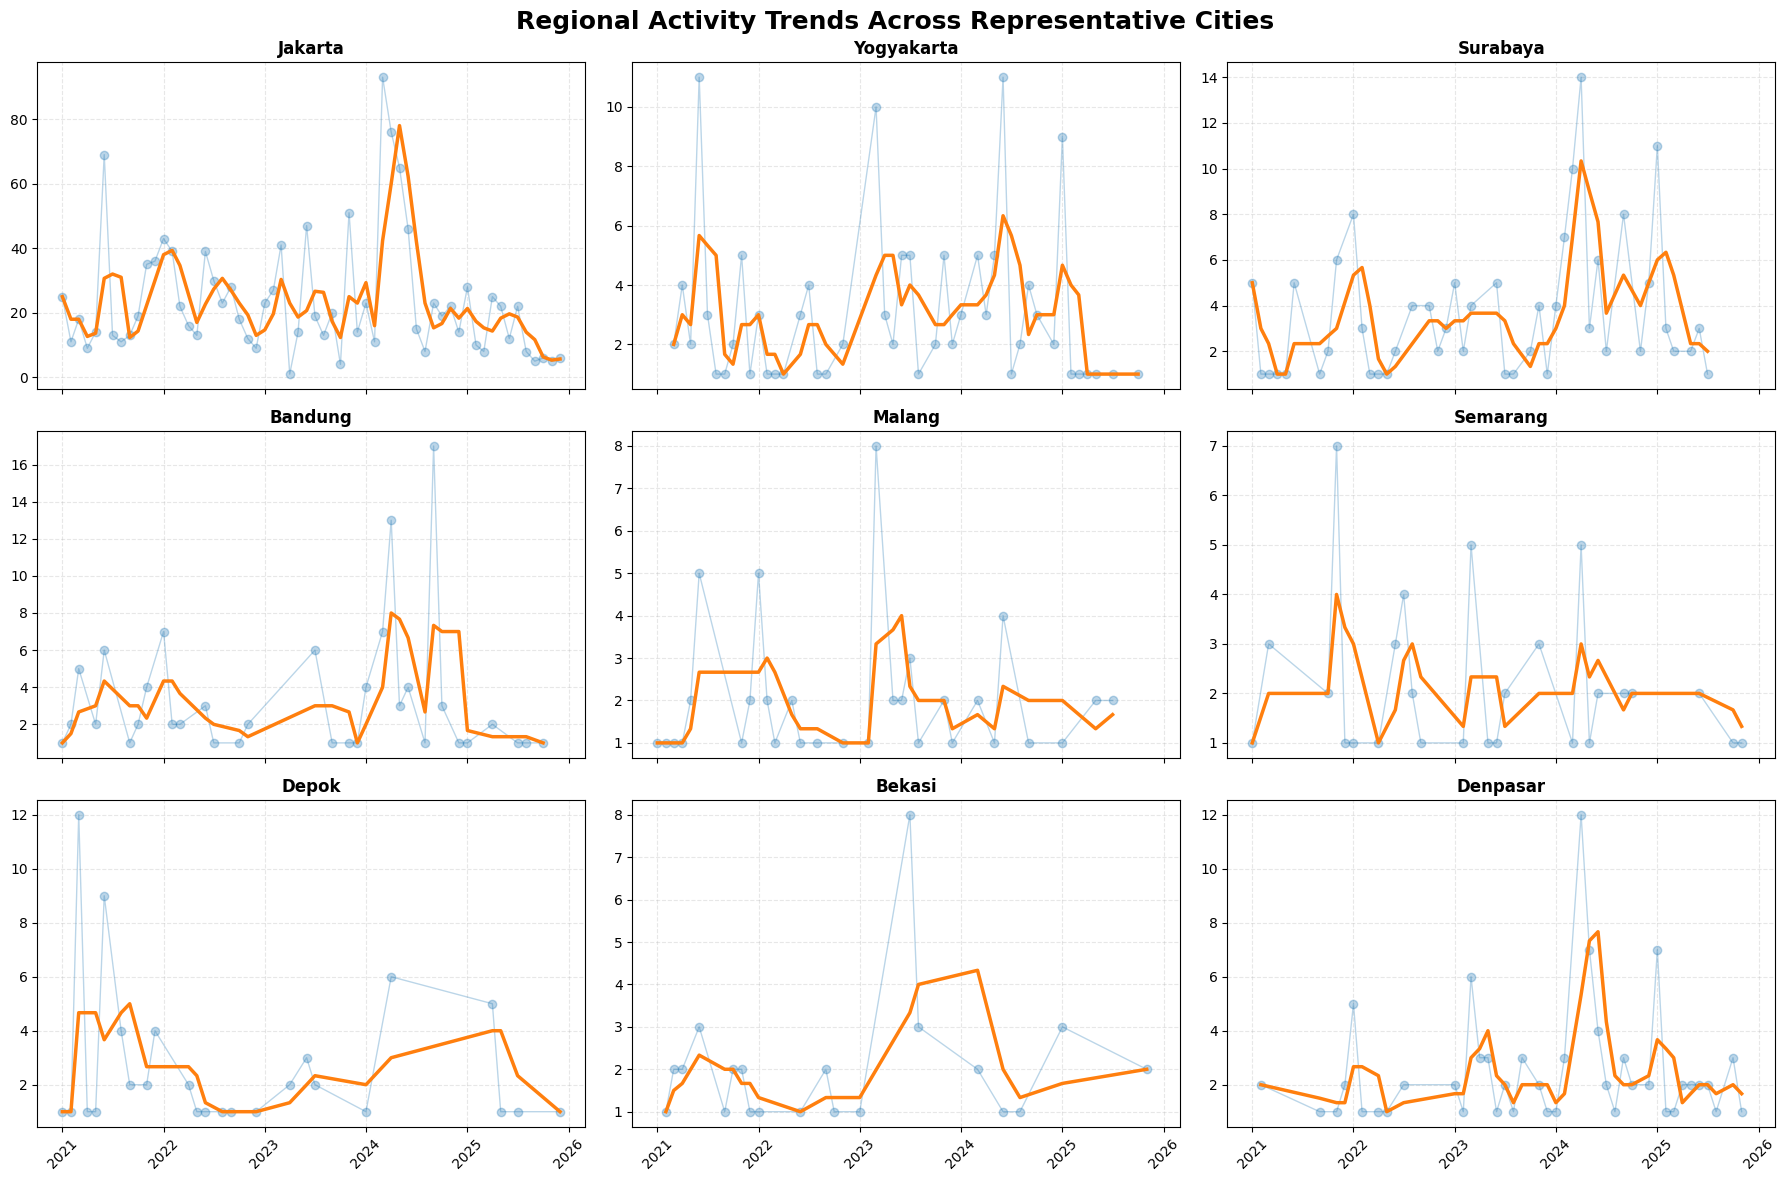

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18,12),
    sharex=True
)

axes = axes.flatten()

for ax, city in zip(
    axes,
    selected_cities
):

    temp = city_monthly[
        city_monthly["city_clean"] == city
    ]

    ax.plot(
        temp["month"],
        temp["tweet_count"],
        alpha=0.3,
        marker="o",
        linewidth=1
    )

    ax.plot(
        temp["month"],
        temp["rolling_3m"],
        linewidth=2.5
    )

    ax.set_title(
        city.title(),
        fontsize=12,
        weight="bold"
    )

    ax.grid(
        linestyle="--",
        alpha=0.3
    )

for ax in axes:
    ax.tick_params(
        axis="x",
        rotation=45
    )

plt.suptitle(
    "Regional Activity Trends Across Representative Cities",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

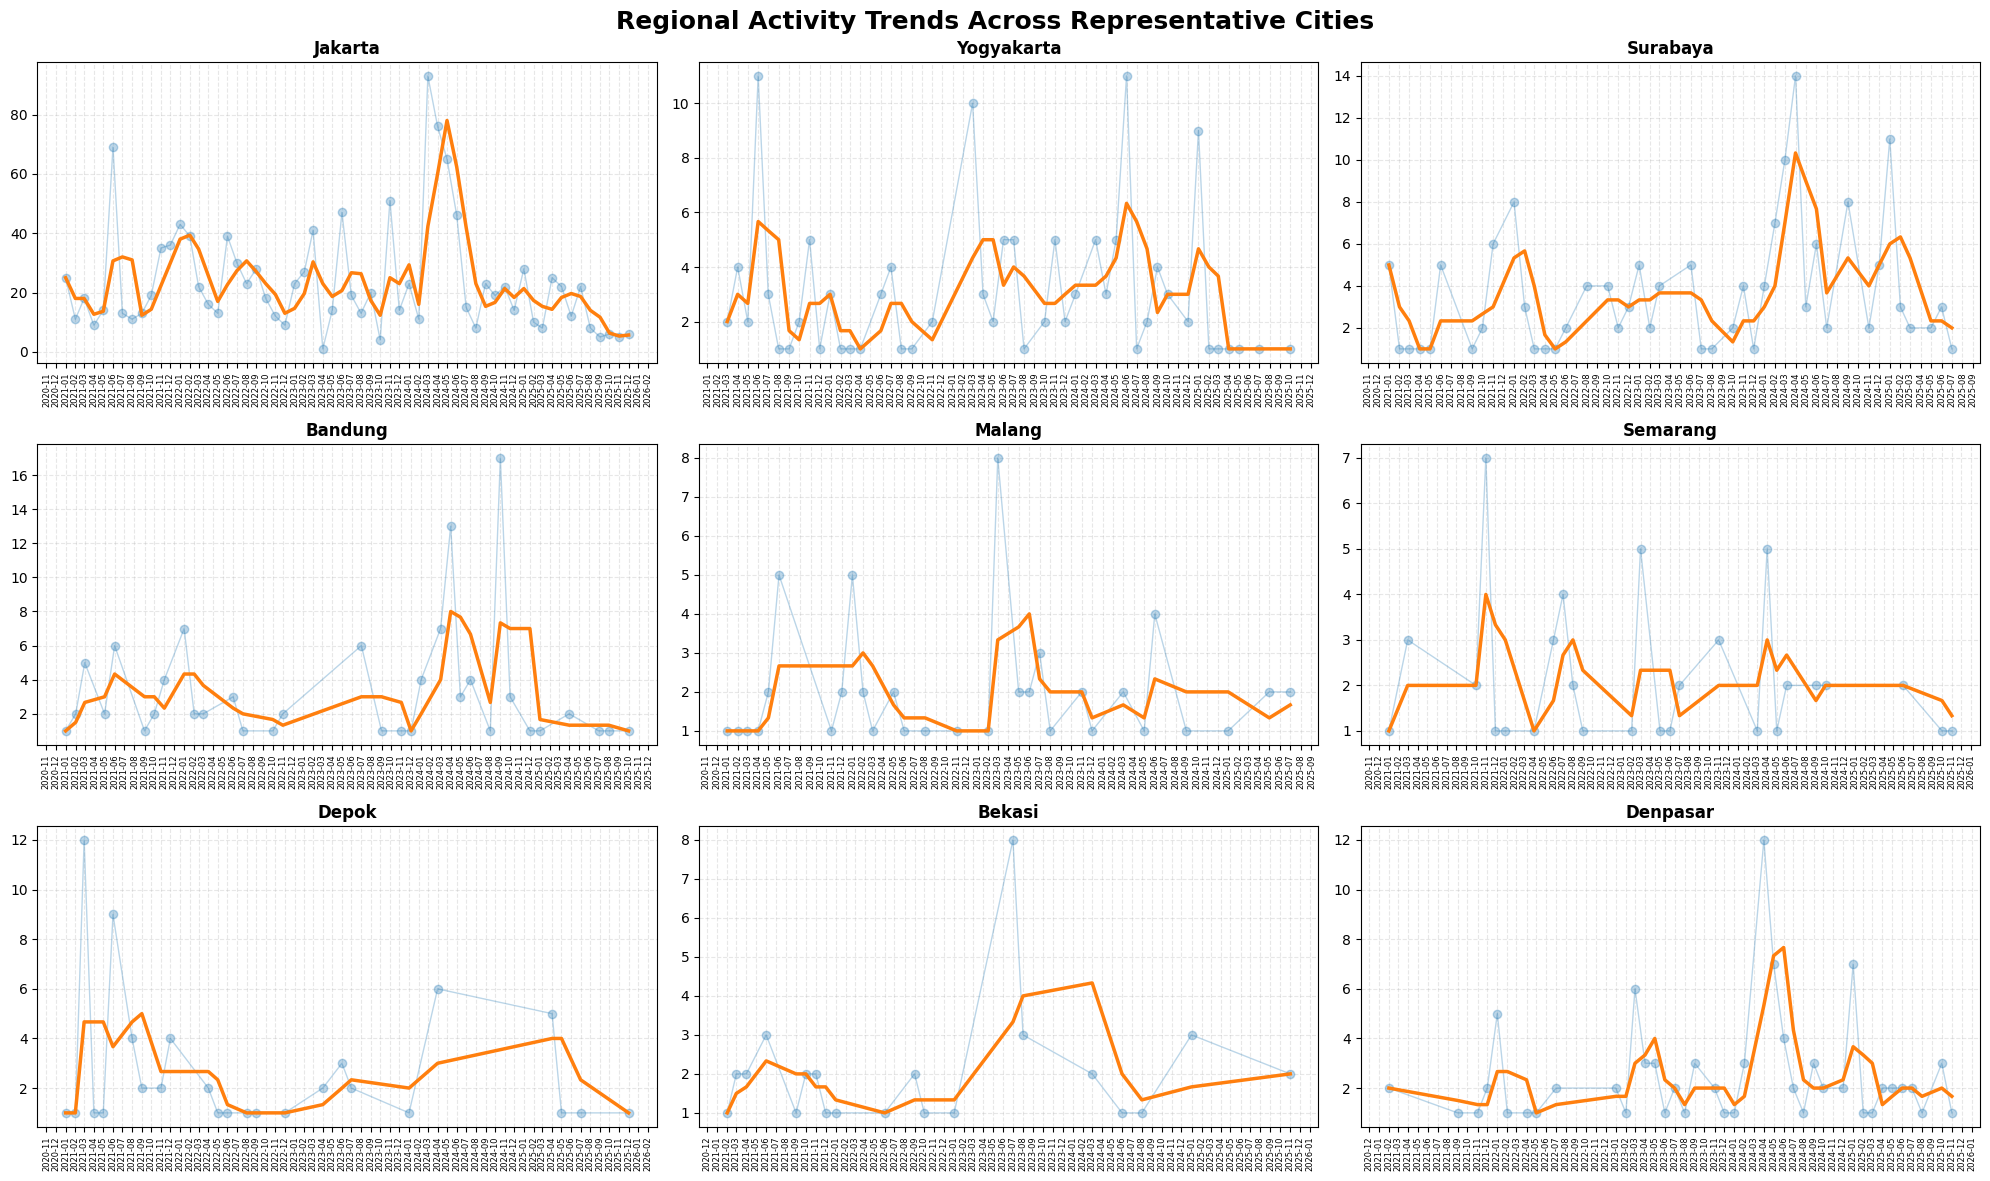

In [35]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    3,
    figsize=(20,12),
    sharex=False
)

axes = axes.flatten()

for ax, city in zip(
    axes,
    selected_cities
):

    temp = city_monthly[
        city_monthly["city_clean"] == city
    ]

    ax.plot(
        temp["month"],
        temp["tweet_count"],
        alpha=0.3,
        marker="o",
        linewidth=1,
        label="Monthly Tweets"
    )

    ax.plot(
        temp["month"],
        temp["rolling_3m"],
        linewidth=2.5,
        label="3-Month MA"
    )

    ax.set_title(
        city.title(),
        fontsize=12,
        weight="bold"
    )

    ax.grid(
        linestyle="--",
        alpha=0.3
    )

    # label tiap bulan
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=1)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )

    ax.tick_params(
        axis="x",
        rotation=90,
        labelsize=6
    )

plt.suptitle(
    "Regional Activity Trends Across Representative Cities",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [36]:
city_monthly.head()

,city_clean,created_at,tweet_count,month,rolling_3m
0,bandung,2021-01,1,2021-01-01,1.000000
1,bandung,2021-02,2,2021-02-01,1.500000
2,bandung,2021-03,5,2021-03-01,2.666667
3,bandung,2021-05,2,2021-05-01,3.000000
4,bandung,2021-06,6,2021-06-01,4.333333


In [ ]:
city_monthly.to_excel(
    os.path.join(OUTPUT_DIR, "city_monthly.xlsx"),
    index=False
)

Seasonality Heatmap

In [38]:
df["year"] = df["created_at"].dt.year

df["month"] = df["created_at"].dt.month

In [39]:
seasonality = (
    df.groupby(
        ["year", "month"]
    )
    .size()
    .reset_index(
        name="tweet_count"
    )
)

In [40]:
heatmap_data = (
    seasonality
    .pivot(
        index="year",
        columns="month",
        values="tweet_count"
    )
    .fillna(0)
)

In [41]:
heatmap_data.columns = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec"
]

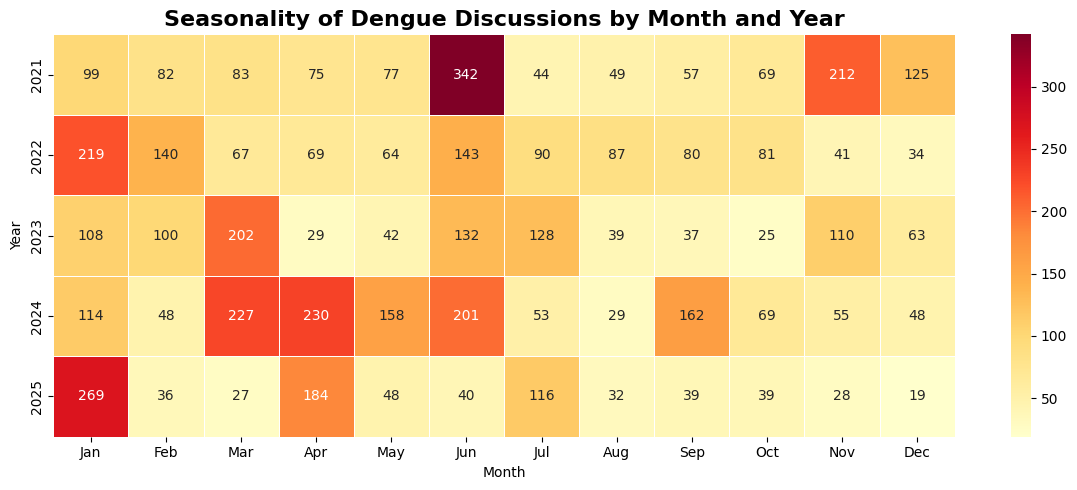

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12,5)
)

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Seasonality of Dengue Discussions by Month and Year",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()

plt.savefig(
    "seasonality_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
heatmap_data

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2021,99,82,83,75,77,342,44,49,57,69,212,125
2022,219,140,67,69,64,143,90,87,80,81,41,34
2023,108,100,202,29,42,132,128,39,37,25,110,63
2024,114,48,227,230,158,201,53,29,162,69,55,48
2025,269,36,27,184,48,40,116,32,39,39,28,19


In [ ]:
heatmap_data.to_excel(
    os.path.join(OUTPUT_DIR, "seasonality_heatmap.xlsx")
)